['Delta_phi', 'dphi_ds', 'D_i']


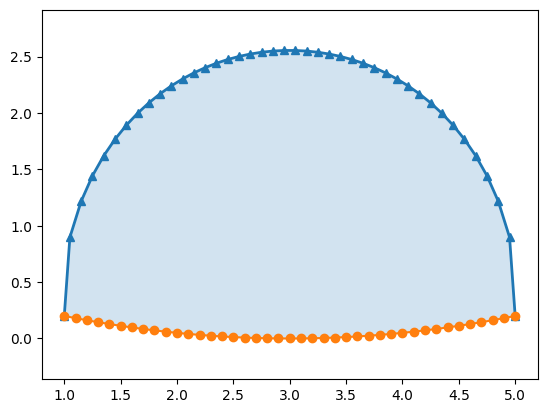

In [40]:
import numpy as np
import pyomo 
from pyomo.contrib.edi import Formulation
from pyomo.environ import units
import matplotlib.pyplot as plt
%matplotlib inline

y_half = np.linspace(1,5,41)
z_half = 0.05*(y_half-(y_half[-1]-y_half[0])/2 - y_half[0])**2

y = (y_half[1:] + y_half[0:-1])/2
z = (z_half[1:] + z_half[0:-1])/2

Delta_s = ( (y_half[1:] - y_half[0:-1])**2 + (z_half[1:] - z_half[0:-1])**2 )**0.5

n_hat_y = -(z_half[1:] - z_half[0:-1])/Delta_s
n_hat_z = (y_half[1:] - y_half[0:-1])/Delta_s

# plt.plot(y_half, z_half, 'o-')
# plt.plot(y,z,'o')
# for i in range(0, len(n_hat_y)):
#     plt.plot([y[i], y[i] + n_hat_y[i]], [z[i], z[i] + n_hat_z[i]], 'r-')
# plt.axis('equal')



f = Formulation()

Delta_phi  = f.Variable(name='Delta_phi' , guess=1.0, units='', size=len(y), description='The potentials')
# Grad_phi_y = f.Variable(name='Grad_phi_y', guess=1.0, units='', size=len(y), description='Grads?')
# Grad_phi_z = f.Variable(name='Grad_phi_z', guess=1.0, units='', size=len(y), description='Grads also?')
dphi_ds    = f.Variable(name='dphi_ds'   , guess=1.0, units='', size=len(y), description='dphi_ds')
D_i        = f.Variable(name='D_i'       , guess=1.0, units='',              description='Induced Drag')


L_spec     = f.Constant(name='L_spec', value=10.0 , units='', description='Specified Lift')
rho        = f.Constant(name='rho',    value=1.23, units='', description='Density')
V          = f.Constant(name='V',      value=1.0 , units='', description='Velocity')

f.Objective(D_i)

constraints = []

# for i in range(0, len(y)):
#     constraints += [Delta_phi[i] >= .00001]
#     constraints += [Delta_phi[i] <= 10000000]
    # constraints += [Grad_phi_y[i] >= .01]
    # constraints += [Grad_phi_z[i] >= .01]


temp_holder = 0
for i in range(0, len(y)):
    temp_holder += Delta_phi[i] * (y_half[i+1]-y_half[i])
constraints += [L_spec <= rho * V * temp_holder]

for i in range(0, len(y)):
    temp_holder = 0
    for j in range(0, len(y_half)):
        if j == 0:
            temp_holder += (                - Delta_phi[j] ) * -(z[i]-z_half[j]) / ( (y[i]-y_half[j])**2 + (z[i]-z_half[j])**2 )
        elif j == len(y_half)-1:
            temp_holder += ( Delta_phi[j-1]                ) * -(z[i]-z_half[j]) / ( (y[i]-y_half[j])**2 + (z[i]-z_half[j])**2 )
        else:
            temp_holder += ( Delta_phi[j-1] - Delta_phi[j] ) * -(z[i]-z_half[j]) / ( (y[i]-y_half[j])**2 + (z[i]-z_half[j])**2 )
    Grad_phi_y = 1/(2*np.pi) * temp_holder

    temp_holder = 0
    for j in range(0, len(y_half)):
        if j == 0:
            temp_holder += (                - Delta_phi[j] ) * (y[i]-y_half[j]) / ( (y[i]-y_half[j])**2 + (z[i]-z_half[j])**2 )
        elif j == len(y_half)-1:
            temp_holder += ( Delta_phi[j-1]                ) * (y[i]-y_half[j]) / ( (y[i]-y_half[j])**2 + (z[i]-z_half[j])**2 )
        else:
            temp_holder += ( Delta_phi[j-1] - Delta_phi[j] ) * (y[i]-y_half[j]) / ( (y[i]-y_half[j])**2 + (z[i]-z_half[j])**2 )
    Grad_phi_z = 1/(2*np.pi) * temp_holder


    constraints += [dphi_ds[i] >= -1*(Grad_phi_y * n_hat_y[i] + Grad_phi_z * n_hat_z[i]) ]


temp_holder = 0
for i in range(0, len(y)):
    temp_holder += Delta_phi[i] * dphi_ds[i] * Delta_s[i]
constraints += [D_i >= 1/2 * rho * V * temp_holder ]

f.ConstraintList(constraints)

# f.pprint()

from solver import cvxopt_solve
res = cvxopt_solve(f)
# print(res['x'])

vars = f.get_variables()
print([str(v) for v in vars])
post_Delta_phi = res['x'][0:len(y)]
post_Delta_phi = np.array(post_Delta_phi).T[0]
y_with_ends = np.append(np.append(y_half[0],y),y_half[-1])
z_with_ends = np.append(np.append(z_half[0],z),z_half[-1])
dp_with_ends = np.append(np.append(0,post_Delta_phi),0)
plt.plot(y_with_ends,dp_with_ends+z_with_ends,'^-',lw=2)
plt.axis('equal')

plt.fill_between(y_with_ends, z_with_ends, dp_with_ends+z_with_ends, alpha=0.2)

plt.plot(y_half, z_half, 'o-')


In [29]:
print(z_half)
print(np.array(post_Delta_phi).T[0])

[0.4   0.361 0.324 0.289 0.256 0.225 0.196 0.169 0.144 0.121 0.1   0.081
 0.064 0.049 0.036 0.025 0.016 0.009 0.004 0.001 0.    0.001 0.004 0.009
 0.016 0.025 0.036 0.049 0.064 0.081 0.1   0.121 0.144 0.169 0.196 0.225
 0.256 0.289 0.324 0.361 0.4  ]
[0.70818778 1.046324   1.28994574 1.48433524 1.646652   1.78555364
 1.90612333 2.01164086 2.10436213 2.18591094 2.25749541 2.32003626
 2.37424712 2.42068697 2.45979548 2.4919175  2.51732025 2.53620548
 2.54871795 2.55495123 2.55495123 2.54871795 2.53620548 2.51732025
 2.4919175  2.45979548 2.42068697 2.37424712 2.32003626 2.25749541
 2.18591094 2.10436213 2.01164086 1.90612333 1.78555364 1.646652
 1.48433524 1.28994574 1.046324   0.70818778]
